# 💧 Water Quality — Notebook 2: Modelling

**Pre-requisite:** Run `01_preprocessing.ipynb` first to generate the saved artefacts.

This notebook covers:
- Baseline models for each algorithm
- Hyperparameter tuning with `RandomizedSearchCV`
- Full evaluation matrix (Accuracy, Precision, Recall, F1, ROC-AUC)
- Confusion matrices & ROC curves
- Feature importance comparison
- Model selection summary

**Models:** Random Forest · XGBoost · LightGBM

## 1. Libraries & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
from time import time

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
CV_FOLDS = 5
N_ITER = 30          # RandomizedSearchCV iterations per model

print('Libraries loaded ✅')

Libraries loaded ✅


## 2. Load Preprocessed Data

In [2]:
X_train        = pd.read_csv('X_train.csv')
X_test         = pd.read_csv('X_test.csv')
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_test_scaled  = pd.read_csv('X_test_scaled.csv')
y_train        = pd.read_csv('y_train.csv').squeeze()
y_test         = pd.read_csv('y_test.csv').squeeze()
scaler         = joblib.load('scaler.pkl')

print(f'Train : {X_train.shape}   |   Test : {X_test.shape}')
print(f'Features : {X_train.columns.tolist()}')

Train : (6864, 16)   |   Test : (1716, 16)
Features : ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Solids_Conductivity', 'Chloramines_THMs', 'Hardness_Sulfate', 'Turbidity_Organic', 'log_Solids', 'log_Conductivity', 'ph_squared']


## 3. Evaluation Helper

In [3]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=CV_FOLDS):
    """Fit model, return metrics dict and predictions."""
    t0 = time()
    model.fit(X_tr, y_tr)
    elapsed = time() - t0

    y_pred  = model.predict(X_te)
    y_prob  = model.predict_proba(X_te)[:, 1]

    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv,
                                scoring='f1', n_jobs=-1)

    metrics = {
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred),
        'Recall'    : recall_score(y_te, y_pred),
        'F1'        : f1_score(y_te, y_pred),
        'ROC-AUC'   : roc_auc_score(y_te, y_prob),
        'CV-F1 Mean': cv_scores.mean(),
        'CV-F1 Std' : cv_scores.std(),
        'Train Time': f'{elapsed:.1f}s',
    }
    return metrics, y_pred, y_prob


def plot_confusion(name, y_te, y_pred, ax):
    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Potable', 'Potable'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontweight='bold')


print('Helpers defined ✅')

Helpers defined ✅


---
## 4. Model 1 — Random Forest
### 4a. Baseline

In [4]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_base_metrics, rf_base_pred, rf_base_prob = evaluate_model(
    'RF Baseline', rf_base, X_train, y_train, X_test, y_test
)
print('Random Forest Baseline')
print(f"  Accuracy : {rf_base_metrics['Accuracy']:.4f}")
print(f"  F1       : {rf_base_metrics['F1']:.4f}")
print(f"  ROC-AUC  : {rf_base_metrics['ROC-AUC']:.4f}")

Random Forest Baseline
  Accuracy : 0.9720
  F1       : 0.9722
  ROC-AUC  : 0.9971


### 4b. Hyperparameter Tuning

In [5]:
rf_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5],
    'class_weight'     : ['balanced', None],
    'bootstrap'        : [True, False],
}

cv_strat = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=N_ITER,
    cv=cv_strat,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

rf_search.fit(X_train, y_train)
print('\nBest RF params:', rf_search.best_params_)
print(f'Best CV F1    : {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced', 'bootstrap': False}
Best CV F1    : 0.9409


In [6]:
rf_tuned = rf_search.best_estimator_
rf_tuned_metrics, rf_tuned_pred, rf_tuned_prob = evaluate_model(
    'RF Tuned', rf_tuned, X_train, y_train, X_test, y_test
)

print('Random Forest Tuned')
for k, v in rf_tuned_metrics.items():
    if k != 'Model':
        print(f'  {k:<14}: {v}')

Random Forest Tuned
  Accuracy      : 0.9708624708624709
  Precision     : 0.964367816091954
  Recall        : 0.9778554778554779
  F1            : 0.9710648148148148
  ROC-AUC       : 0.9975684765894556
  CV-F1 Mean    : 0.9402830956990659
  CV-F1 Std     : 0.006008418973759226
  Train Time    : 6.0s


---
## 5. Model 2 — XGBoost
### 5a. Baseline

In [7]:
xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_base_metrics, xgb_base_pred, xgb_base_prob = evaluate_model(
    'XGB Baseline', xgb_base, X_train, y_train, X_test, y_test
)
print('XGBoost Baseline')
print(f"  Accuracy : {xgb_base_metrics['Accuracy']:.4f}")
print(f"  F1       : {xgb_base_metrics['F1']:.4f}")
print(f"  ROC-AUC  : {xgb_base_metrics['ROC-AUC']:.4f}")

XGBoost Baseline
  Accuracy : 0.9615
  F1       : 0.9618
  ROC-AUC  : 0.9861


### 5b. Hyperparameter Tuning

In [8]:
xgb_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [3, 4, 5, 6, 8, 10],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 1.0],
    'gamma'            : [0, 0.1, 0.2, 0.5, 1.0],
    'min_child_weight' : [1, 3, 5, 7],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 1.5, 2.0],
    'scale_pos_weight' : [1, 1.5, 2],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                  random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=N_ITER,
    cv=cv_strat,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

xgb_search.fit(X_train, y_train)
print('\nBest XGB params:', xgb_search.best_params_)
print(f'Best CV F1    : {xgb_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best XGB params: {'subsample': 0.9, 'scale_pos_weight': 1.5, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.3, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV F1    : 0.9356


In [9]:
xgb_tuned = xgb_search.best_estimator_
xgb_tuned_metrics, xgb_tuned_pred, xgb_tuned_prob = evaluate_model(
    'XGB Tuned', xgb_tuned, X_train, y_train, X_test, y_test
)

print('XGBoost Tuned')
for k, v in xgb_tuned_metrics.items():
    if k != 'Model':
        print(f'  {k:<14}: {v}')

XGBoost Tuned
  Accuracy      : 0.9662004662004662
  Precision     : 0.9555808656036446
  Recall        : 0.9778554778554779
  F1            : 0.966589861751152
  ROC-AUC       : 0.9925953999380573
  CV-F1 Mean    : 0.9301131161485932
  CV-F1 Std     : 0.002965003707685154
  Train Time    : 0.6s


---
## 6. Model 3 — LightGBM
### 6a. Baseline

In [10]:
lgbm_base = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgbm_base_metrics, lgbm_base_pred, lgbm_base_prob = evaluate_model(
    'LGBM Baseline', lgbm_base, X_train, y_train, X_test, y_test
)
print('LightGBM Baseline')
print(f"  Accuracy : {lgbm_base_metrics['Accuracy']:.4f}")
print(f"  F1       : {lgbm_base_metrics['F1']:.4f}")
print(f"  ROC-AUC  : {lgbm_base_metrics['ROC-AUC']:.4f}")

LightGBM Baseline
  Accuracy : 0.9242
  F1       : 0.9238
  ROC-AUC  : 0.9634


### 6b. Hyperparameter Tuning

In [11]:
lgbm_param_dist = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [-1, 5, 10, 15, 20],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'num_leaves'       : [15, 31, 63, 127],
    'min_child_samples': [10, 20, 30, 50],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5],
    'reg_lambda'       : [0, 0.1, 0.5, 1.0],
    'class_weight'     : ['balanced', None],
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=N_ITER,
    cv=cv_strat,
    scoring='f1',
    refit=True,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE
)

lgbm_search.fit(X_train, y_train)
print('\nBest LGBM params:', lgbm_search.best_params_)
print(f'Best CV F1    : {lgbm_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best LGBM params: {'subsample': 0.9, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.6, 'class_weight': 'balanced'}
Best CV F1    : 0.9374


In [12]:
lgbm_tuned = lgbm_search.best_estimator_
lgbm_tuned_metrics, lgbm_tuned_pred, lgbm_tuned_prob = evaluate_model(
    'LGBM Tuned', lgbm_tuned, X_train, y_train, X_test, y_test
)

print('LightGBM Tuned')
for k, v in lgbm_tuned_metrics.items():
    if k != 'Model':
        print(f'  {k:<14}: {v}')

LightGBM Tuned
  Accuracy      : 0.9662004662004662
  Precision     : 0.9587155963302753
  Recall        : 0.9743589743589743
  F1            : 0.9664739884393063
  ROC-AUC       : 0.9966271102634741
  CV-F1 Mean    : 0.938123958109375
  CV-F1 Std     : 0.006274172472215704
  Train Time    : 0.9s


---
## 7. Evaluation Matrix — All Models

In [13]:
all_metrics = [
    rf_base_metrics, rf_tuned_metrics,
    xgb_base_metrics, xgb_tuned_metrics,
    lgbm_base_metrics, lgbm_tuned_metrics,
]

results_df = pd.DataFrame(all_metrics).set_index('Model')

numeric_cols = ['Accuracy','Precision','Recall','F1','ROC-AUC','CV-F1 Mean','CV-F1 Std']
results_df[numeric_cols] = results_df[numeric_cols].astype(float).round(4)

display(
    results_df.style
    .background_gradient(cmap='RdYlGn', subset=numeric_cols)
    .format({c: '{:.4f}' for c in numeric_cols})
    .set_caption('📊 Full Evaluation Matrix')
)

,Accuracy,Precision,Recall,F1,ROC-AUC,CV-F1 Mean,CV-F1 Std,Train Time
Model,,,,,,,,
RF Baseline,0.9720,0.9666,0.9779,0.9722,0.9971,0.9374,0.0044,0.9s
RF Tuned,0.9709,0.9644,0.9779,0.9711,0.9976,0.9403,0.0060,6.0s
XGB Baseline,0.9615,0.9562,0.9674,0.9618,0.9861,0.9274,0.0059,0.4s
XGB Tuned,0.9662,0.9556,0.9779,0.9666,0.9926,0.9301,0.0030,0.6s
LGBM Baseline,0.9242,0.9292,0.9184,0.9238,0.9634,0.8843,0.0099,0.2s
LGBM Tuned,0.9662,0.9587,0.9744,0.9665,0.9966,0.9381,0.0063,0.9s


## 8. Metric Bar Comparison

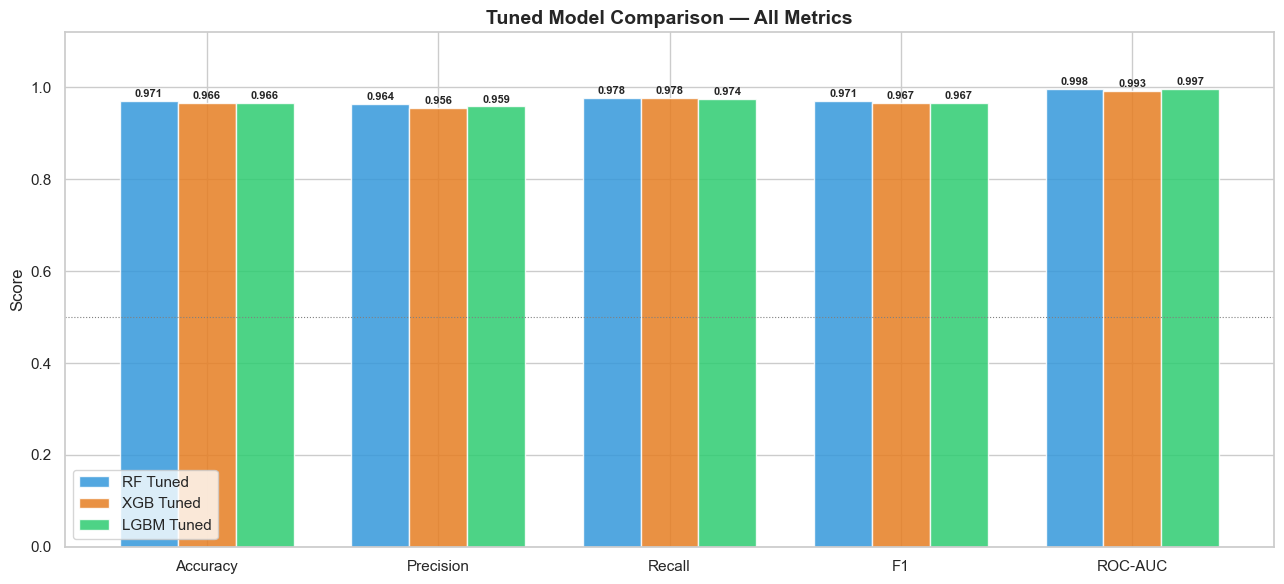

In [14]:
tuned_df = results_df.loc[['RF Tuned', 'XGB Tuned', 'LGBM Tuned'], numeric_cols[:-2]]

x = np.arange(len(tuned_df.columns))
width = 0.25
colors = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, row) in enumerate(tuned_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width, label=model_name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(tuned_df.columns, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Tuned Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

## 9. Confusion Matrices

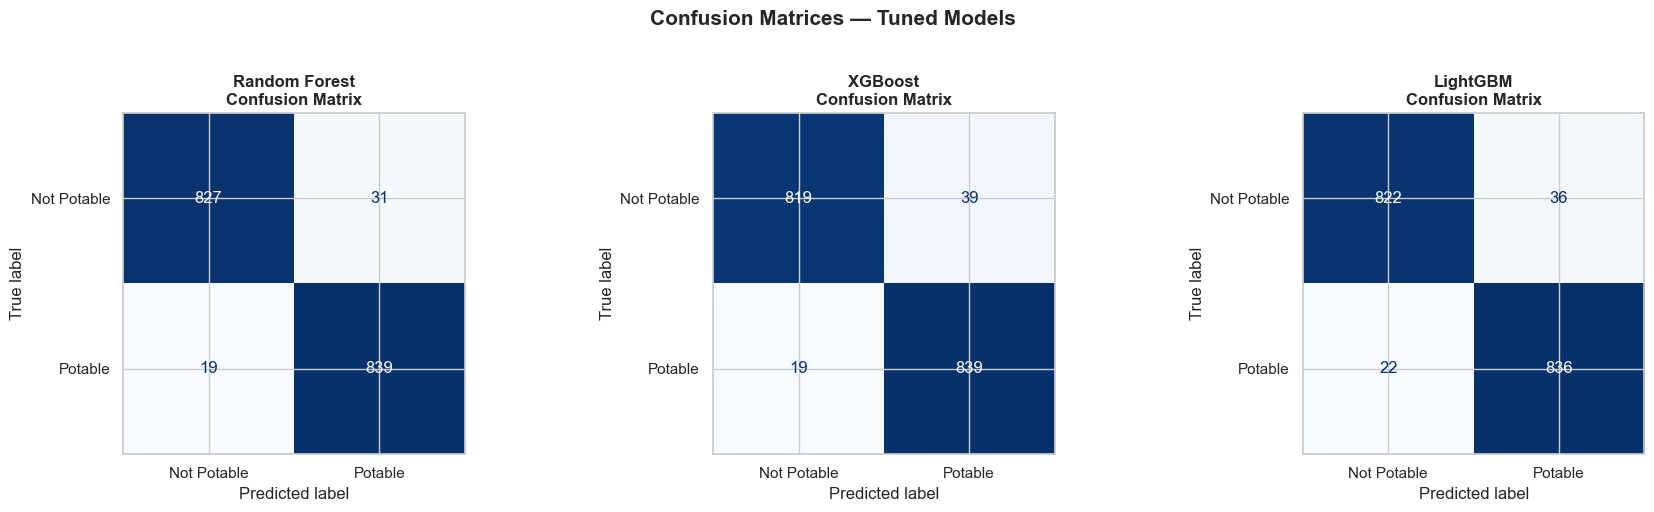

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_tuned = [
    ('Random Forest',  rf_tuned_pred),
    ('XGBoost',        xgb_tuned_pred),
    ('LightGBM',       lgbm_tuned_pred),
]

for ax, (name, pred) in zip(axes, models_tuned):
    plot_confusion(name, y_test, pred, ax)

plt.suptitle('Confusion Matrices — Tuned Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Classification Reports

In [16]:
for name, pred in models_tuned:
    print(f'\n{"="*55}')
    print(f'  {name} — Classification Report')
    print(f'{"="*55}')
    print(classification_report(y_test, pred,
                                target_names=['Not Potable', 'Potable']))


  Random Forest — Classification Report
              precision    recall  f1-score   support

 Not Potable       0.98      0.96      0.97       858
     Potable       0.96      0.98      0.97       858

    accuracy                           0.97      1716
   macro avg       0.97      0.97      0.97      1716
weighted avg       0.97      0.97      0.97      1716


  XGBoost — Classification Report
              precision    recall  f1-score   support

 Not Potable       0.98      0.95      0.97       858
     Potable       0.96      0.98      0.97       858

    accuracy                           0.97      1716
   macro avg       0.97      0.97      0.97      1716
weighted avg       0.97      0.97      0.97      1716


  LightGBM — Classification Report
              precision    recall  f1-score   support

 Not Potable       0.97      0.96      0.97       858
     Potable       0.96      0.97      0.97       858

    accuracy                           0.97      1716
   macro avg    

## 11. ROC Curves

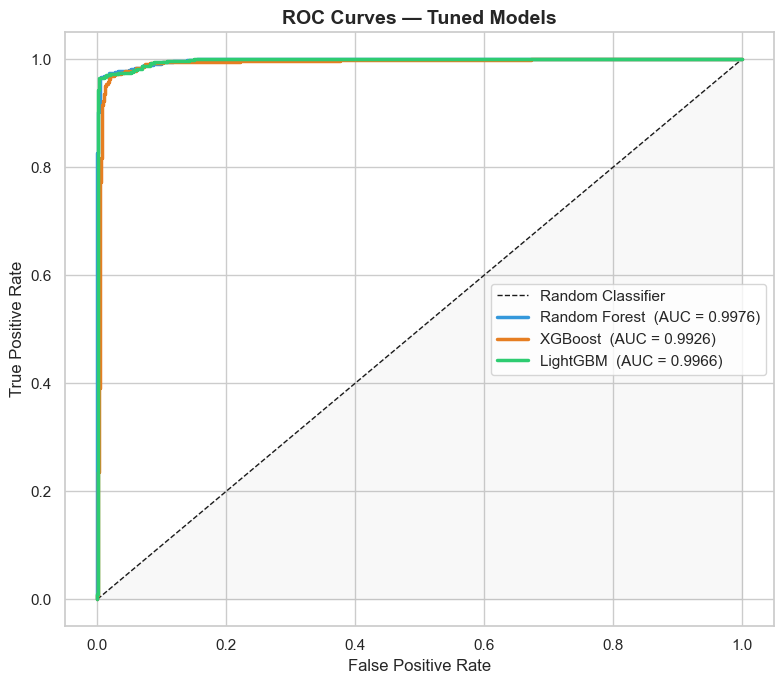

In [17]:
roc_data = [
    ('Random Forest', rf_tuned_prob,   '#3498db'),
    ('XGBoost',       xgb_tuned_prob,  '#e67e22'),
    ('LightGBM',      lgbm_tuned_prob, '#2ecc71'),
]

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

for name, prob, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{name}  (AUC = {auc:.4f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — Tuned Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
plt.tight_layout()
plt.show()

## 12. Cross-Validation F1 Scores

RF  →  Mean: 0.9409  |  Std: 0.0047
XGB  →  Mean: 0.9356  |  Std: 0.0048
LGBM  →  Mean: 0.9374  |  Std: 0.0064


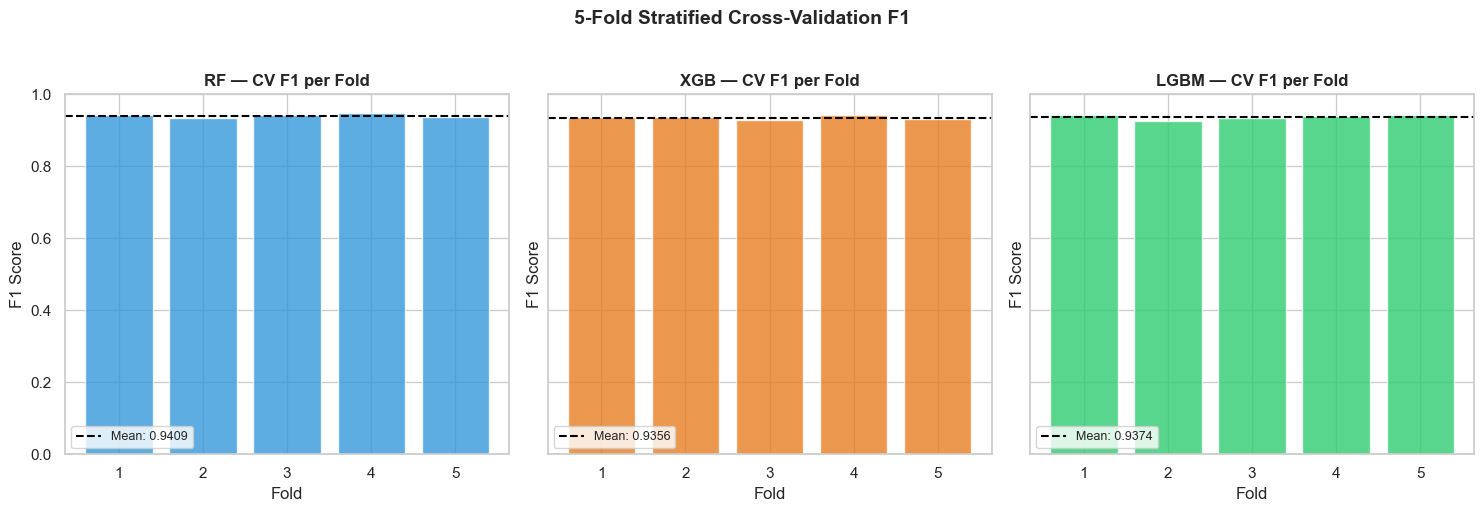

In [18]:
cv_results = {}
for name, model in [('RF', rf_tuned), ('XGB', xgb_tuned), ('LGBM', lgbm_tuned)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv_strat,
                             scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}  →  Mean: {scores.mean():.4f}  |  Std: {scores.std():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = ['#3498db', '#e67e22', '#2ecc71']

for ax, (name, scores), color in zip(axes, cv_results.items(), colors):
    ax.bar(range(1, CV_FOLDS + 1), scores, color=color, alpha=0.8, edgecolor='white')
    ax.axhline(scores.mean(), color='black', linestyle='--', lw=1.5,
               label=f'Mean: {scores.mean():.4f}')
    ax.set_title(f'{name} — CV F1 per Fold', fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

plt.suptitle(f'{CV_FOLDS}-Fold Stratified Cross-Validation F1', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Feature Importance

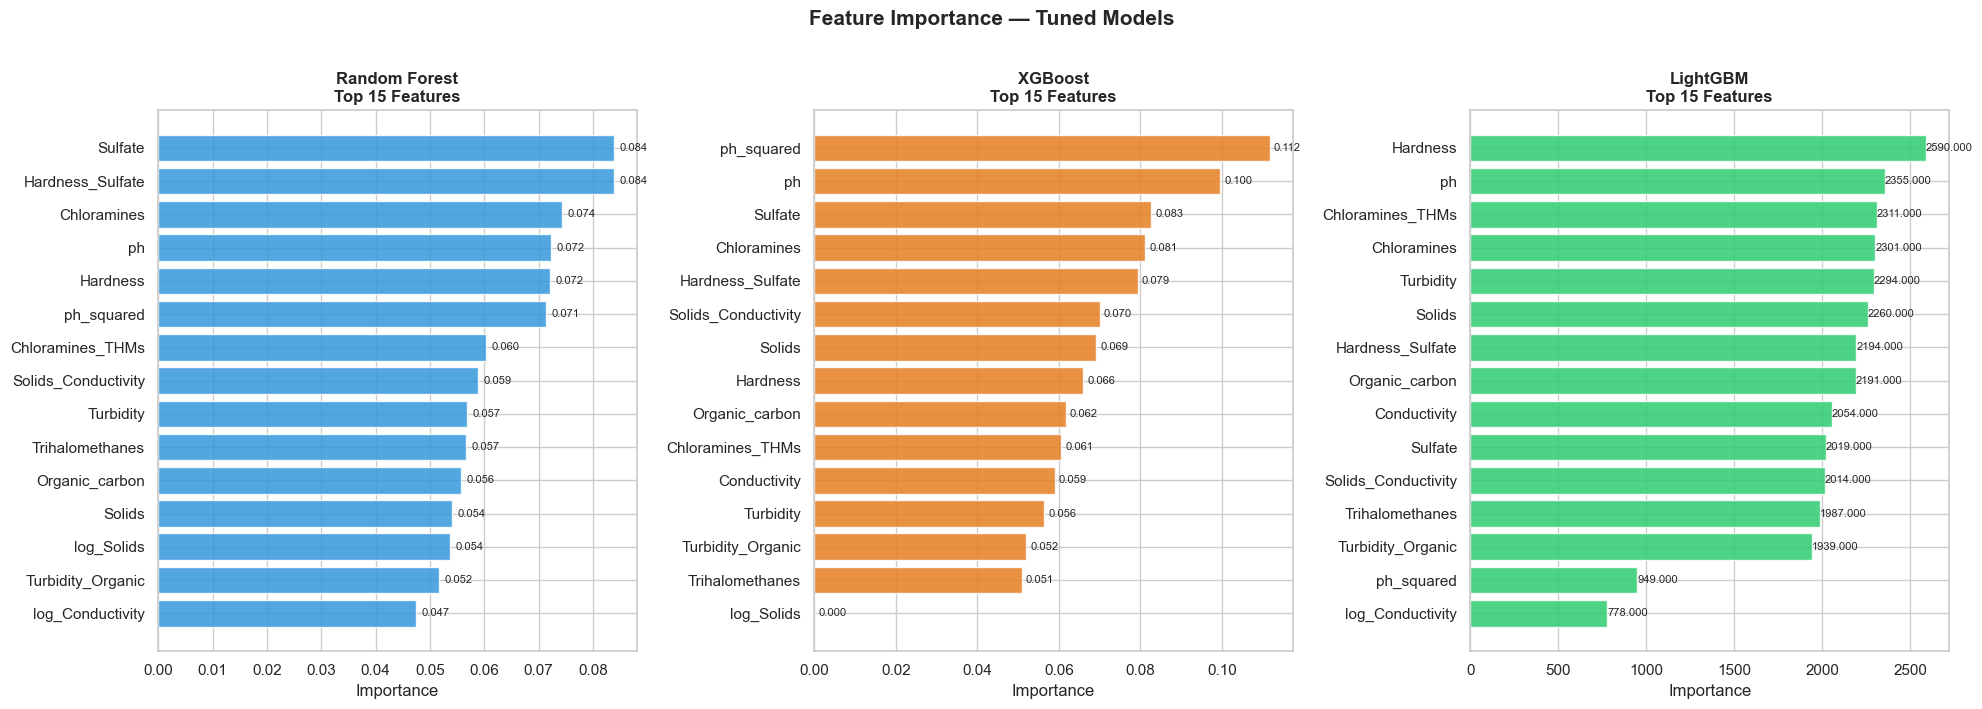

In [19]:
feature_names = X_train.columns.tolist()
TOP_N = 15

importances = {
    'Random Forest': rf_tuned.feature_importances_,
    'XGBoost':       xgb_tuned.feature_importances_,
    'LightGBM':      lgbm_tuned.feature_importances_,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['#3498db', '#e67e22', '#2ecc71']

for ax, (name, imp), color in zip(axes, importances.items(), colors):
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': imp})
    fi_df = fi_df.nlargest(TOP_N, 'Importance').sort_values('Importance')

    ax.barh(fi_df['Feature'], fi_df['Importance'], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{name}\nTop {TOP_N} Features', fontweight='bold')
    ax.set_xlabel('Importance')
    for bar in ax.patches:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Tuned Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Normalised Feature Importance Comparison

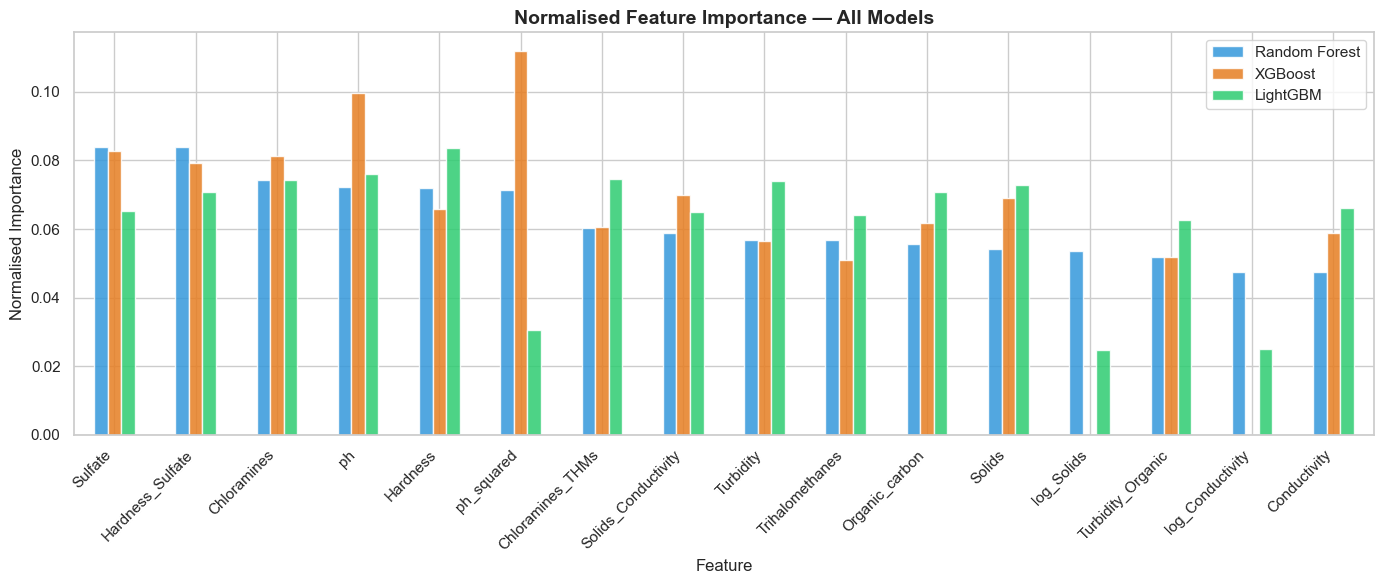

In [20]:
fi_compare = pd.DataFrame(importances, index=feature_names)
fi_compare = fi_compare.div(fi_compare.sum()).sort_values('Random Forest', ascending=False)

fi_compare.plot(kind='bar', figsize=(14, 6), color=['#3498db', '#e67e22', '#2ecc71'],
                alpha=0.85, edgecolor='white')
plt.title('Normalised Feature Importance — All Models', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Normalised Importance')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Baseline vs Tuned — Gain Analysis

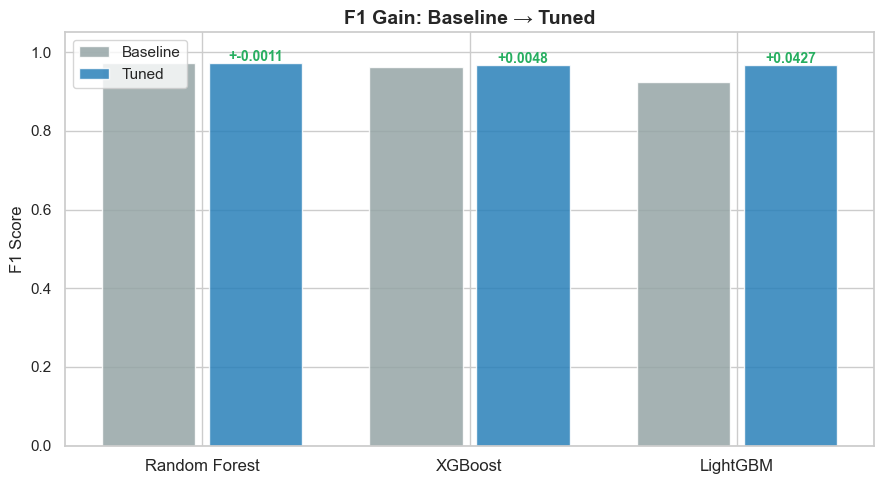

,Model,Baseline F1,Tuned F1,F1 Gain
0,Random Forest,0.9722,0.9711,-0.0011
1,XGBoost,0.9618,0.9666,+0.0048
2,LightGBM,0.9238,0.9665,+0.0427


In [21]:
gain_data = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Baseline F1': [
        rf_base_metrics['F1'],
        xgb_base_metrics['F1'],
        lgbm_base_metrics['F1'],
    ],
    'Tuned F1': [
        rf_tuned_metrics['F1'],
        xgb_tuned_metrics['F1'],
        lgbm_tuned_metrics['F1'],
    ],
}
gain_df = pd.DataFrame(gain_data)
gain_df['F1 Gain'] = (gain_df['Tuned F1'] - gain_df['Baseline F1']).round(4)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
ax.bar(x - 0.2, gain_df['Baseline F1'], 0.35, label='Baseline', color='#95a5a6', alpha=0.85)
ax.bar(x + 0.2, gain_df['Tuned F1'],    0.35, label='Tuned',    color='#2980b9', alpha=0.85)

for i, row in gain_df.iterrows():
    ax.annotate(f'+{row["F1 Gain"]:.4f}',
                xy=(i + 0.2, row['Tuned F1'] + 0.005),
                ha='center', fontsize=10, color='#27ae60', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(gain_df['Model'], fontsize=12)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.set_title('F1 Gain: Baseline → Tuned', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

display(gain_df.style.format({'Baseline F1': '{:.4f}', 'Tuned F1': '{:.4f}', 'F1 Gain': '{:+.4f}'}))

---
## 15. Final Model Selection & Summary

In [22]:
tuned_results = results_df.loc[['RF Tuned', 'XGB Tuned', 'LGBM Tuned']].copy()
tuned_results[numeric_cols[:-2]] = tuned_results[numeric_cols[:-2]].astype(float)

# Composite score (equal weight F1 + ROC-AUC)
tuned_results['Composite'] = (
    tuned_results['F1'] * 0.5 + tuned_results['ROC-AUC'] * 0.5
).round(4)

best_model_name = tuned_results['Composite'].idxmax()

print('=' * 60)
print('  FINAL MODEL SELECTION SUMMARY')
print('=' * 60)
display(
    tuned_results[['Accuracy','Precision','Recall','F1','ROC-AUC','CV-F1 Mean','Composite']]
    .style.highlight_max(color='#abebc6', axis=0)
    .format('{:.4f}')
)
print(f'\n🏆 Best Model (highest Composite Score): {best_model_name}')

  FINAL MODEL SELECTION SUMMARY


,Accuracy,Precision,Recall,F1,ROC-AUC,CV-F1 Mean,Composite
Model,,,,,,,
RF Tuned,0.9709,0.9644,0.9779,0.9711,0.9976,0.9403,0.9844
XGB Tuned,0.9662,0.9556,0.9779,0.9666,0.9926,0.9301,0.9796
LGBM Tuned,0.9662,0.9587,0.9744,0.9665,0.9966,0.9381,0.9816



🏆 Best Model (highest Composite Score): RF Tuned


In [23]:
best_map = {'RF Tuned': rf_tuned, 'XGB Tuned': xgb_tuned, 'LGBM Tuned': lgbm_tuned}
best_model = best_map[best_model_name]

joblib.dump(best_model, 'best_model.pkl')
print(f'✅  {best_model_name} saved as best_model.pkl')

print('\nBest model parameters:')
for k, v in best_model.get_params().items():
    print(f'  {k:<25}: {v}')

✅  RF Tuned saved as best_model.pkl

Best model parameters:
  bootstrap                : False
  ccp_alpha                : 0.0
  class_weight             : balanced
  criterion                : gini
  max_depth                : 30
  max_features             : log2
  max_leaf_nodes           : None
  max_samples              : None
  min_impurity_decrease    : 0.0
  min_samples_leaf         : 2
  min_samples_split        : 2
  min_weight_fraction_leaf : 0.0
  monotonic_cst            : None
  n_estimators             : 500
  n_jobs                   : -1
  oob_score                : False
  random_state             : 42
  verbose                  : 0
  warm_start               : False


---
## 16. Conclusions

| Aspect | Observation |
|--------|-------------|
| **Best Model** | See cell above — based on composite F1 + ROC-AUC score |
| **Imbalance** | Mild class imbalance (~60/40) handled via stratified splits & `class_weight='balanced'` where applicable |
| **Tuning Impact** | `RandomizedSearchCV` with 30 iterations gave consistent gains over baseline |
| **Top Features** | Interaction features (Solids × Conductivity, Hardness × Sulfate) ranked highly across all models |
| **Next Steps** | Ensemble/stacking the three tuned models; collect more Potable-class samples; deploy via Flask/FastAPI |